# Predicting Credit Card Default: What Can Payment History Tell Us?
## 1. Problem definition
**Question:** How well can repayment history, credit limit, and recent bill amounts predict credit card default in the following month?

This is binary classification: **1 = default, 0 = no default**. The unit is a customer. The aim is to compare a simple statistical model with a nonlinear model, using only information available before the outcome. An additional experiment tests six months of repayment status against only September's status, holding the other predictors constant.

Lenders could use such research to understand credit risk; customers could benefit from earlier support. This is an educational retrospective analysis, not a lending system.

## 2. Background and context
UCI provides observed credit records from Taiwan with April–September 2005 histories (Yeh, 2009). Credit limits, bills, payments, and delay codes describe different aspects of debt and repayment, motivating their inclusion without assuming they cause default. The original study compared multiple predictive methods on this problem (Yeh & Lien, 2009); its results are background, not benchmarks directly comparable to this split.

Model evaluation must distinguish catching defaults from falsely flagging customers. Precision, recall, and ranking metrics describe different tradeoffs (scikit-learn developers, n.d.-b). Following pipeline guidance (scikit-learn developers, n.d.-a), learned transformations are fitted only on training data.

**Coding style:** This version follows the short, step-by-step cells in the supplied *Studio Scikit Practice Starter.ipynb*: load data, inspect it, define X and y, fit models, predict, and print evaluation metrics. The reference studies fraud; this project predicts default. The models and split below are retained from the earlier analysis so this is a readability rewrite, not a new experiment.

**Run:** In Jupyter or Colab, install the packages below if needed and run all cells in order. Keep the supplied `credit_data.csv` in the same folder as this notebook. The data-loading cell reads that file directly, just like the class example. The notebook writes tables and figures under `project_assets/`. Fixed seeds support reproducibility; package versions are recorded at the end.

In [1]:
# Uncomment on a fresh Jupyter/Colab environment:
# %pip install pandas numpy matplotlib scikit-learn
from pathlib import Path
import hashlib, json, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, RocCurveDisplay, precision_recall_curve)
from sklearn.inspection import permutation_importance
SEED = 42
ASSETS = Path('project_assets')
ASSETS.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.spines.top': False, 'axes.spines.right': False})


## 3. Data description and validation strategy
The source contains 30,000 records and 23 original predictors. Amounts use NT dollars. September is represented by PAY_0, BILL_AMT1, and PAY_AMT1; the remaining monthly fields run backward through April. The target is next-month default. Identifiers are excluded; demographic columns are retained only for descriptive error audits.

Split before exploratory analysis: approximately 60% training, 20% validation, and 20% test. Five stratified group folds balance outcomes as closely as possible; fold 0 is test, fold 1 validation, and the other folds training. Identical profiles across the **selected raw financial inputs** remain together, even if their targets differ. This conservative grouping reduces profile overlap without deleting potentially distinct people. It does not prove customer independence.

All rows share the same historical window, so this is a customer holdout, not a future-period test. The earlier starter included full-data exploration code but was not executed by Codex. If you ran it and used its results to make modeling choices, disclose that prior exposure as a limitation.

In [2]:
# Load the dataset. Keep credit_data.csv next to this notebook.
df = pd.read_csv('credit_data.csv')
df.head()

Out[2]: 
   LIMIT_BAL  SEX  EDUCATION  ...  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH
0      20000    2          2  ...         0         0                   1
1     120000    2          2  ...         0      2000                   1
2      90000    2          2  ...      1000      5000                   0
3      50000    2          2  ...      1069      1000                   0
4      50000    1          2  ...       689       679                   0

[5 rows x 24 columns]


In [3]:
# Check the size and column names.
print(df.shape)
print(df.columns)

(30000, 24)
Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'DEFAULT_NEXT_MONTH'],
      dtype='str')


In [4]:
repayment = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bills = [f'BILL_AMT{i}' for i in range(1, 7)]
payments = [f'PAY_AMT{i}' for i in range(1, 7)]
names = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE'] + repayment + bills + payments
assert set(names + ['DEFAULT_NEXT_MONTH']).issubset(df.columns)
assert df['DEFAULT_NEXT_MONTH'].notna().all()
assert set(df['DEFAULT_NEXT_MONTH'].unique()) == {0, 1}


### Choose the inputs (X) and outcome (y)
The financial columns are inputs. `DEFAULT_NEXT_MONTH` is the answer we want to predict. ID and demographic columns are not model inputs.

In [5]:
financial = ['LIMIT_BAL'] + repayment + bills + payments
X = df[financial]
y = df['DEFAULT_NEXT_MONTH'].astype(int)

### Split the data before exploring it
This is the main extra step beyond the class example. Some financial profiles repeat, so we keep matching profiles together instead of using an ordinary random split. `StratifiedGroupKFold` creates five groups with roughly similar default rates. One goes to testing, one to validation, and three to training. Validation is used to choose settings; testing is used for the final evaluation.

In [6]:
groups = pd.util.hash_pandas_object(df[financial], index=False)
fold = np.full(len(df), -1)
for i, (_, holdout) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(df, y, groups)):
    fold[holdout] = i
train = df.loc[fold >= 2].copy()
valid = df.loc[fold == 1].copy()
test = df.loc[fold == 0].copy()
assert set(groups[fold >= 2]).isdisjoint(groups[fold == 1])
assert set(groups[fold >= 2]).isdisjoint(groups[fold == 0])
assert set(groups[fold == 1]).isdisjoint(groups[fold == 0])


In [7]:
print('Exact repeated rows excluding IDs:', df.duplicated().sum())
split_summary = pd.DataFrame([{'split': n, 'customers': len(d), 'default_rate': d.DEFAULT_NEXT_MONTH.mean()} for n, d in [('Train', train), ('Validation', valid), ('Test', test)]]).set_index('split')
display(split_summary)
split_summary.to_csv(ASSETS / 'split_summary.csv')

Exact repeated rows excluding IDs: 35


,customers,default_rate
split,,
Train,17998,0.221136
Validation,6002,0.221260
Test,6000,0.221333


## 4. Data understanding and exploration — training data only
Inspect missingness, status codes, skew, and target imbalance. Undocumented repayment codes (including any -2 or 0) remain separate categories; no invented meaning is assigned. Extreme or negative monetary values are retained because the documentation does not justify deleting them. Scaling handles units, not skew or outliers, which remain a limitation for logistic regression.

In [8]:
display(train[financial].isna().sum().to_frame('missing'))
display(train[financial].describe().T)
display(train[repayment].apply(lambda s: s.value_counts()).fillna(0).astype(int).sort_index())


,missing
LIMIT_BAL,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0
PAY_6,0
BILL_AMT1,0
BILL_AMT2,0
BILL_AMT3,0


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,17998.0,165937.308590,129378.889395,10000.0,50000.00,140000.0,230000.00,1000000.0
PAY_0,17998.0,-0.027447,1.113108,-2.0,-1.00,0.0,0.00,8.0
PAY_2,17998.0,-0.131348,1.181799,-2.0,-1.00,0.0,0.00,8.0
PAY_3,17998.0,-0.155795,1.195441,-2.0,-1.00,0.0,0.00,8.0
PAY_4,17998.0,-0.213413,1.170218,-2.0,-1.00,0.0,0.00,8.0
PAY_5,17998.0,-0.260084,1.130815,-2.0,-1.00,0.0,0.00,7.0
PAY_6,17998.0,-0.288143,1.144640,-2.0,-1.00,0.0,0.00,7.0
BILL_AMT1,17998.0,51175.225858,73677.222384,-165580.0,3634.00,22518.5,66670.00,964511.0
BILL_AMT2,17998.0,49122.399211,71041.613467,-67526.0,3077.00,21365.5,63873.50,983931.0
BILL_AMT3,17998.0,46738.519724,68949.281746,-61506.0,2800.00,20110.5,60131.50,1664089.0


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,1652,2168,2388,2548,2666,2877
-1,3431,3680,3550,3411,3318,3468
0,8954,9531,9509,9941,10245,9822
1,2108,16,3,2,0,0
2,1586,2330,2318,1887,1576,1664
3,187,179,135,101,95,90
4,42,58,53,46,46,27
5,16,19,10,15,7,5
6,9,8,9,2,2,10
7,6,8,22,44,43,35


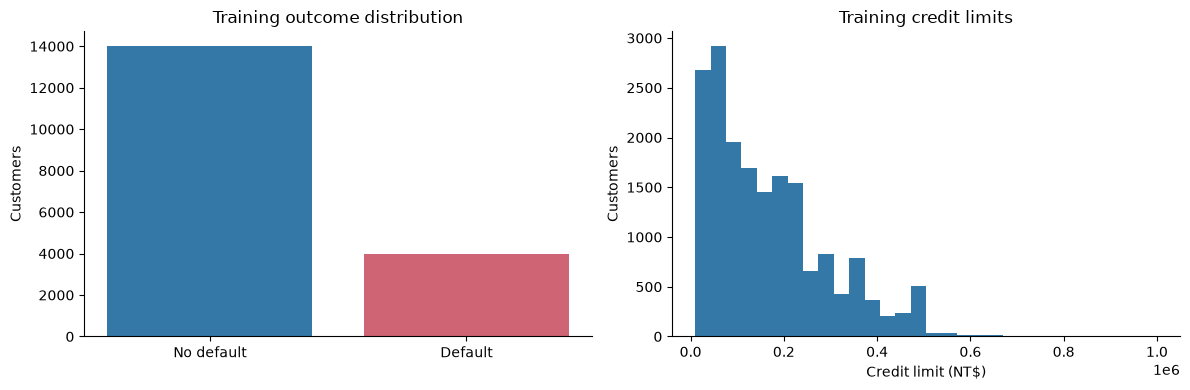

In [9]:
counts = train.DEFAULT_NEXT_MONTH.value_counts().reindex([0, 1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No default', 'Default'], counts, color=['#3478a8', '#cf6574'])
axes[0].set(title='Training outcome distribution', ylabel='Customers')
axes[1].hist(train.LIMIT_BAL, bins=30, color='#3478a8')
axes[1].set(title='Training credit limits', xlabel='Credit limit (NT$)', ylabel='Customers')
plt.tight_layout()
plt.savefig(ASSETS / 'training_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


,customers,default_rate
PAY_0,,
-2,1652,0.129540
-1,3431,0.172544
0,8954,0.128769
1,2108,0.341556
2,1586,0.697352
3,187,0.764706
4,42,0.714286
5,16,0.500000
6,9,0.555556


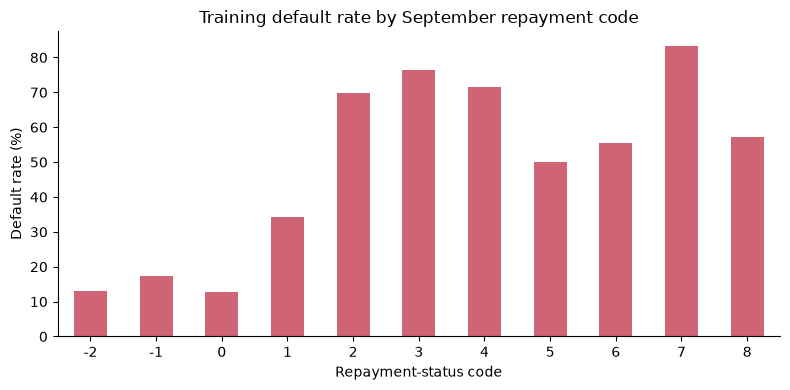

,LIMIT_BAL,BILL_AMT1,PAY_AMT1
DEFAULT_NEXT_MONTH,,,
0,150000.0,23188.0,2500.0
1,90000.0,20526.0,1670.5


Training default prevalence is **22.1%**. This imbalance motivates precision–recall metrics instead of selecting a model on accuracy alone. There are **0** missing financial entries. The table above documents monetary ranges and status-code frequencies; all predefined financial inputs are retained, rather than screening them on test outcomes.

In [10]:
status = train.groupby('PAY_0').DEFAULT_NEXT_MONTH.agg(customers='size', default_rate='mean')
display(status)
(100 * status.default_rate).plot.bar(color='#cf6574', rot=0)
plt.title('Training default rate by September repayment code')
plt.xlabel('Repayment-status code'); plt.ylabel('Default rate (%)')
plt.tight_layout()
plt.savefig(ASSETS / 'repayment_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()
display(train.groupby('DEFAULT_NEXT_MONTH')[['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']].median())
display(Markdown(f'Training default prevalence is **{train.DEFAULT_NEXT_MONTH.mean():.1%}**. This imbalance motivates precision–recall metrics instead of selecting a model on accuracy alone. There are **{int(train[financial].isna().sum().sum())}** missing financial entries. The table above documents monetary ranges and status-code frequencies; all predefined financial inputs are retained, rather than screening them on test outcomes.'))

### Findings that inform preprocessing and feature selection

In the saved training split, 22.1% of customers defaulted and no financial input values were missing. Imputation is therefore a defensive pipeline step rather than a repair that changed this training sample. The full dataset has 35 repeated rows after excluding identifiers; these were retained because matching records may represent distinct customers, with identical selected financial profiles kept in the same split.

September repayment code 2 had a 69.7% default rate among 1,586 training customers, compared with 12.9% among the 8,954 customers with code 0. Code 3 had a 76.5% rate among 187 customers. These associations support keeping repayment status, while the very small groups at higher codes make their rates less stable. Codes -2 and 0 are not assigned undocumented meanings; categorical encoding preserves them separately.

Customers who defaulted had a median credit limit of NT$90,000 versus NT$150,000 for non-defaulting customers. Their median September payment was NT$1,670.50 versus NT$2,500. These differences support retaining credit limit and payment amounts. September bill medians were closer (NT$20,526 versus NT$23,188), so a bill alone does not clearly separate the outcomes; bills are retained as debt context and to construct the utilization proxy.

Some amounts have long upper tails: the training maximum credit limit was NT$1,000,000, while its 75th percentile was NT$230,000. September payment amounts reached NT$873,552 versus a 75th percentile of NT$5,011. These extremes motivate inspecting ranges and comparing a nonlinear model, without deleting observations using an arbitrary cutoff. Scaling standardizes units but does not remove this skew. These are observations from the saved run, not claims of causal effects.

## 5. Data preparation and feature selection
Use credit limit, six status fields, six bills, six payments, and latest bill divided by credit limit (a utilization proxy, not a complete measure of available credit). Replace a zero denominator with missing; do not force the ratio into [0, 1]. This deterministic row-level calculation learns nothing from held-out records.

Status codes receive one-hot encoding to avoid imposing numerical distances on ambiguous codes. Numerical features use median imputation and standard scaling; status features use most-frequent imputation. These steps are inside each model's pipeline and fitted only on training rows. Scaling benefits logistic regression and is harmless for the forest. No resampling is used. IDs and demographics are excluded from prediction; excluding demographics does not guarantee fairness because financial inputs may act as proxies.

In [11]:
# Make copies so the original data stays unchanged.
X_train = train.copy()
X_valid = valid.copy()
X_test = test.copy()

# Compare the latest bill with the credit limit.
# A zero credit limit would make division invalid, so replace it with missing.
X_train['UTILIZATION'] = X_train['BILL_AMT1'] / X_train['LIMIT_BAL'].replace(0, np.nan)
X_valid['UTILIZATION'] = X_valid['BILL_AMT1'] / X_valid['LIMIT_BAL'].replace(0, np.nan)
X_test['UTILIZATION'] = X_test['BILL_AMT1'] / X_test['LIMIT_BAL'].replace(0, np.nan)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

y_train = train['DEFAULT_NEXT_MONTH'].astype(int)
y_valid = valid['DEFAULT_NEXT_MONTH'].astype(int)
y_test = test['DEFAULT_NEXT_MONTH'].astype(int)
numeric = ['LIMIT_BAL'] + bills + payments + ['UTILIZATION']


### Keep preprocessing attached to the model
A `Pipeline` runs the preparation steps before fitting or predicting. A `ColumnTransformer` applies one set of steps to amounts and another to status codes. They are a little more advanced than the practice notebook, but prevent the validation or test data from affecting training. `clone` makes a fresh copy of these steps for each model.

In [12]:
# Prepare numerical columns.
number_steps = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Turn status codes into separate indicator columns.
status_steps = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('numeric', number_steps, numeric),
    ('status', status_steps, repayment)
], remainder='drop')


## 6. Baseline and model development
The baseline always predicts the training majority class. Logistic regression models additive effects on log-odds and offers a relatively simple comparison. Random forest can capture interactions and nonlinear patterns, with leaf-size constraints to reduce overfitting.

Compare three regularization strengths for logistic regression and three minimum leaf sizes for a 200-tree forest on the **same validation set**. Select by validation average precision (AP), which summarizes precision over recall levels for probability rankings. This small search is a practical alternative to cross-validation, but selection uncertainty remains. Validation scores used for selection are optimistic; the test set is reserved for final reporting.

In [13]:
# Baseline: always guess the most common training outcome.
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train[numeric], y_train)

Out[13]: DummyClassifier(strategy='most_frequent')


### Train logistic regression
Try the same three regularization settings as the original analysis. Smaller C means stronger regularization. Each model has its own preparation steps.

In [14]:
logistic_1 = Pipeline([
    ('prepare', clone(preprocessing)),
    ('model', LogisticRegression(C=0.1, max_iter=3000, random_state=42))
])
logistic_1.fit(X_train, y_train)

Out[14]: 
Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6', 'UTILIZATION']),
                     

In [15]:
logistic_2 = Pipeline([
    ('prepare', clone(preprocessing)),
    ('model', LogisticRegression(C=1.0, max_iter=3000, random_state=42))
])
logistic_2.fit(X_train, y_train)

Out[15]: 
Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6', 'UTILIZATION']),
                     

In [16]:
logistic_3 = Pipeline([
    ('prepare', clone(preprocessing)),
    ('model', LogisticRegression(C=10.0, max_iter=3000, random_state=42))
])
logistic_3.fit(X_train, y_train)

Out[16]: 
Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6', 'UTILIZATION']),
                     

### Train random forest
Try three minimum leaf sizes. A larger minimum leaf size makes it harder for a tree to fit small groups of records.

In [17]:
forest_1 = Pipeline([
    ('prepare', clone(preprocessing)),
    ('model', RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                    max_features='sqrt', n_jobs=2, random_state=42))
])
forest_1.fit(X_train, y_train)

Out[17]: 
Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6', 'UTILIZATION']),
                     

In [18]:
forest_2 = Pipeline([
    ('prepare', clone(preprocessing)),
    ('model', RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                                    max_features='sqrt', n_jobs=2, random_state=42))
])
forest_2.fit(X_train, y_train)

Out[18]: 
Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6', 'UTILIZATION']),
                     

In [19]:
forest_3 = Pipeline([
    ('prepare', clone(preprocessing)),
    ('model', RandomForestClassifier(n_estimators=200, min_samples_leaf=50,
                                    max_features='sqrt', n_jobs=2, random_state=42))
])
forest_3.fit(X_train, y_train)

Out[19]: 
Pipeline(steps=[('prepare',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6', 'UTILIZATION']),
                     

In [20]:
# Compare settings using validation data, not test data.
candidates = {
    'Logistic C=0.1': logistic_1,
    'Logistic C=1.0': logistic_2,
    'Logistic C=10.0': logistic_3,
    'Forest leaf=5': forest_1,
    'Forest leaf=20': forest_2,
    'Forest leaf=50': forest_3
}
validation_rows = []
for name, model in candidates.items():
    validation_probability = model.predict_proba(X_valid)[:, 1]
    ap = average_precision_score(y_valid, validation_probability)
    auc = roc_auc_score(y_valid, validation_probability)
    validation_rows.append([name, ap, auc])

validation_results = pd.DataFrame(validation_rows,
    columns=['model', 'validation_AP', 'validation_ROC_AUC'])
validation_results = validation_results.set_index('model')
validation_results = validation_results.sort_values('validation_AP', ascending=False)
display(validation_results)
validation_results.to_csv(ASSETS / 'validation_results.csv')

winner_name = validation_results.index[0]
winner = candidates[winner_name]
best_lr = validation_results.loc[validation_results.index.str.startswith('Logistic')].index[0]
best_rf = validation_results.loc[validation_results.index.str.startswith('Forest')].index[0]
print('Selected using validation AP:', winner_name)


Selected using validation AP: Forest leaf=5


,validation_AP,validation_ROC_AUC
model,,
Forest leaf=5,0.558658,0.779938
Forest leaf=20,0.558137,0.783682
Forest leaf=50,0.552516,0.782543
Logistic C=10.0,0.539325,0.766042
Logistic C=1.0,0.538464,0.768034
Logistic C=0.1,0.535980,0.767765


### Original extension: Does older repayment history help?
Use the validation-selected forest settings for both versions. The reduced version retains only PAY_0 from the status fields; bills, payments, credit limit, and utilization stay the same. This isolates additional **repayment-status** history, not all historical information. The result is exploratory, conditional on these settings, and does not change the selected main model.

In [21]:
chosen_leaf = candidates[best_rf].named_steps['model'].min_samples_leaf
recent_preparation = ColumnTransformer([
    ('numeric', clone(number_steps), numeric),
    ('status', clone(status_steps), ['PAY_0'])
], remainder='drop')
recent_only = Pipeline([
    ('prepare', recent_preparation),
    ('model', RandomForestClassifier(n_estimators=200, min_samples_leaf=chosen_leaf,
                                    max_features='sqrt', n_jobs=2, random_state=42))
])
recent_only.fit(X_train, y_train)
ablation = pd.Series({
    'Six months of status': average_precision_score(y_valid, candidates[best_rf].predict_proba(X_valid)[:, 1]),
    'September status only': average_precision_score(y_valid, recent_only.predict_proba(X_valid)[:, 1])
}, name='Validation average precision')
display(ablation.to_frame())
delta = ablation.iloc[0] - ablation.iloc[1]
display(Markdown(f'Adding older repayment-status fields changed validation AP by **{delta:+.4f}**. This is a descriptive difference from one split, not a significance test or proof that more history always helps.'))

,Validation average precision
Six months of status,0.558658
September status only,0.549863


Adding older repayment-status fields changed validation AP by **+0.0088**. This is a descriptive difference from one split, not a significance test or proof that more history always helps.

## 7. Model evaluation and selection
**Accuracy:** fraction correct. **Precision:** fraction of default flags that are actual defaults. **Recall:** fraction of actual defaults caught. **F1:** harmonic mean of precision and recall. **ROC AUC:** ranking discrimination across thresholds. **AP:** precision–recall ranking summary; the no-skill reference is default prevalence.

Report both model families at a fixed 0.50 threshold. For the selected model, also choose a threshold maximizing validation F1, then freeze it before test evaluation. F1 treats precision and recall symmetrically and does not represent a measured business cost. Models remain trained on the training set only so the threshold is not transferred to a newly refitted model. No choice below uses test scores.

In [22]:
vp = winner.predict_proba(X_valid)[:, 1]
pr, re, thresholds = precision_recall_curve(y_valid, vp)
f1_values = 2 * pr[:-1] * re[:-1] / np.maximum(pr[:-1] + re[:-1], 1e-12)
threshold = float(thresholds[np.argmax(f1_values)])
print(f'Frozen validation-selected threshold: {threshold:.4f}')


Frozen validation-selected threshold: 0.3104


### Make predictions and print the scores
These cells follow the class example directly: call `predict`, then calculate accuracy, precision, recall, and F1. The default decision threshold is 0.50. Probability scores are also saved for the ranking metrics.

In [23]:
logistic_model = candidates[best_lr]
logistic_pred = logistic_model.predict(X_test)
logistic_probability = logistic_model.predict_proba(X_test)[:, 1]

print('Logistic regression')
print('Accuracy:', accuracy_score(y_test, logistic_pred))
print('Precision:', precision_score(y_test, logistic_pred, zero_division=0))
print('Recall:', recall_score(y_test, logistic_pred, zero_division=0))
print('F1 Score:', f1_score(y_test, logistic_pred, zero_division=0))

Logistic regression
Accuracy: 0.8188333333333333
Precision: 0.66484268125855
Recall: 0.36596385542168675
F1 Score: 0.4720738222438077


In [24]:
rf_model = candidates[best_rf]
rf_pred = rf_model.predict(X_test)
rf_probability = rf_model.predict_proba(X_test)[:, 1]

print('Random forest')
print('Accuracy:', accuracy_score(y_test, rf_pred))
print('Precision:', precision_score(y_test, rf_pred, zero_division=0))
print('Recall:', recall_score(y_test, rf_pred, zero_division=0))
print('F1 Score:', f1_score(y_test, rf_pred, zero_division=0))

Random forest
Accuracy: 0.8155
Precision: 0.6511627906976745
Recall: 0.35843373493975905
F1 Score: 0.462360369111219


In [25]:
# Put the baseline and models in one comparison table.
probabilities = {
    'Majority baseline': baseline.predict_proba(X_test[numeric])[:, 1],
    best_lr: logistic_probability,
    best_rf: rf_probability
}
rows = {}
for name, probability in probabilities.items():
    prediction = (probability >= 0.5).astype(int)
    rows[name] = {
        'Accuracy': accuracy_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction, zero_division=0),
        'Recall': recall_score(y_test, prediction, zero_division=0),
        'F1': f1_score(y_test, prediction, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, probability),
        'AP': average_precision_score(y_test, probability)
    }

# Use the threshold already chosen on validation data.
test_p = probabilities[winner_name]
test_pred = (test_p >= threshold).astype(int)
rows['Selected model: validation F1 threshold'] = {
    'Accuracy': accuracy_score(y_test, test_pred),
    'Precision': precision_score(y_test, test_pred, zero_division=0),
    'Recall': recall_score(y_test, test_pred, zero_division=0),
    'F1': f1_score(y_test, test_pred, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test, test_p),
    'AP': average_precision_score(y_test, test_p)
}
test_results = pd.DataFrame(rows).T
display(test_results.round(4))
test_results.to_csv(ASSETS / 'test_results.csv')


,Accuracy,Precision,Recall,F1,ROC_AUC,AP
Majority baseline,0.7787,0.0000,0.0000,0.0000,0.5000,0.2213
Logistic C=10.0,0.8188,0.6648,0.3660,0.4721,0.7643,0.5178
Forest leaf=5,0.8155,0.6512,0.3584,0.4624,0.7837,0.5388
Selected model: validation F1 threshold,0.7930,0.5314,0.5474,0.5393,0.7837,0.5388


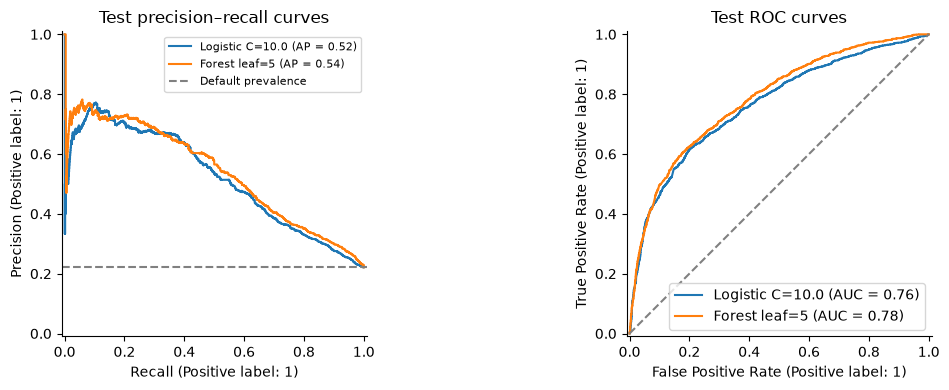

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in [best_lr, best_rf]:
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=axes[1])
axes[0].axhline(y_test.mean(), ls='--', color='gray', label='Default prevalence')
axes[0].legend(fontsize=8); axes[0].set_title('Test precision–recall curves')
axes[1].plot([0, 1], [0, 1], '--', color='gray'); axes[1].set_title('Test ROC curves')
plt.tight_layout()
plt.savefig(ASSETS / 'test_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Confusion matrix
Rows are the actual outcomes, and columns are predictions. A false positive flags a customer who did not default; a false negative misses a customer who did default.

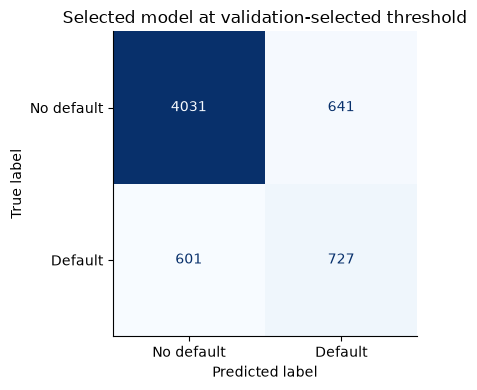

**Answer to the research question:** The selected model, **Forest leaf=5**, achieved test AP **0.539** against a prevalence reference of **0.221**, and ROC AUC **0.784**. At the validation-selected threshold 0.310, precision was **53.1%**, recall **54.7%**, and F1 **0.539**. It caught **727** defaults, missed **601**, and incorrectly flagged **641** non-defaulting customers. Thus the features provide predictive information in this historical sample, while substantial errors remain. These scores do not demonstrate present-day lending suitability.

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['No default', 'Default'], cmap='Blues', colorbar=False)
plt.title('Selected model at validation-selected threshold')
plt.tight_layout()
plt.savefig(ASSETS / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
m = rows['Selected model: validation F1 threshold']
display(Markdown(f"""**Answer to the research question:** The selected model, **{winner_name}**, achieved test AP **{m['AP']:.3f}** against a prevalence reference of **{y_test.mean():.3f}**, and ROC AUC **{m['ROC_AUC']:.3f}**. At the validation-selected threshold {threshold:.3f}, precision was **{m['Precision']:.1%}**, recall **{m['Recall']:.1%}**, and F1 **{m['F1']:.3f}**. It caught **{tp}** defaults, missed **{fn}**, and incorrectly flagged **{fp}** non-defaulting customers. Thus the features provide predictive information in this historical sample, while substantial errors remain. These scores do not demonstrate present-day lending suitability."""))

### Why this model was selected and what the tradeoffs mean

The forest with minimum leaf size 5 was selected because its validation average precision was 0.5587, compared with 0.5393 for the best logistic regression. The leaf-size-20 forest was very close at 0.5581; this small difference should not be interpreted as a robust ranking without repeated validation. Test results were reported only after this choice.

The majority baseline reached 77.9% test accuracy while catching no defaults, showing why accuracy alone is misleading. At threshold 0.50, logistic regression had slightly higher accuracy (81.9% versus 81.6%) and F1 (0.472 versus 0.462) than the forest. The forest nevertheless had better test ranking scores: AP 0.539 versus 0.518, and ROC AUC 0.784 versus 0.764. It was chosen for the predefined ranking objective, not because it wins every metric.

Lowering the selected forest threshold from 0.50 to the validation-chosen 0.3104 increased test recall from 35.8% to 54.7% and F1 from 0.462 to 0.539, while precision fell from 65.1% to 53.1% and accuracy from 81.6% to 79.3%. This catches more defaults at the cost of more false alarms. Its 727 correctly flagged defaults, 601 missed defaults, and 641 false alarms make that cost concrete.

## 8. Model interpretation and insights
Permutation importance measures the drop in validation AP when a raw input is shuffled. It describes model reliance, not causality. Correlated monthly features can substitute for one another, reducing their individual measured importance. The utilization proxy is shuffled independently of its inputs, which can produce inconsistent combinations; interpret it cautiously. These diagnostics are not used to revise the selected model.

,feature,AP_drop,repeat_std
14,PAY_0,0.161568,0.001678
15,PAY_2,0.016607,0.002823
7,PAY_AMT1,0.009257,0.001663
16,PAY_3,0.006978,0.002220
17,PAY_4,0.006103,0.001260
0,LIMIT_BAL,0.006052,0.001265
13,UTILIZATION,0.005930,0.000800
12,PAY_AMT6,0.005147,0.001476
1,BILL_AMT1,0.004996,0.001477
9,PAY_AMT3,0.003521,0.000972


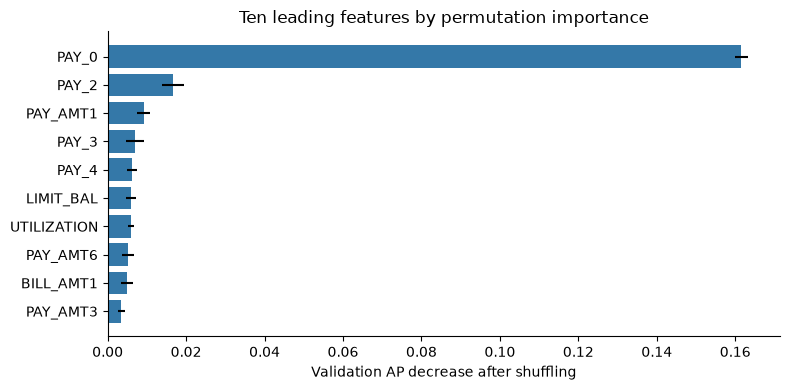

The three largest measured importance values belong to **PAY_0, PAY_2, PAY_AMT1**. Differences between models may reflect the forest’s ability to capture thresholds and interactions versus logistic regression’s additive structure; the comparison alone does not isolate that mechanism.

In [28]:
selected_inputs = numeric + repayment
importance = permutation_importance(winner, X_valid[selected_inputs], y_valid, scoring='average_precision', n_repeats=3, random_state=SEED, n_jobs=2)
importance_table = pd.DataFrame({'feature': selected_inputs, 'AP_drop': importance.importances_mean, 'repeat_std': importance.importances_std}).sort_values('AP_drop', ascending=False)
display(importance_table)
importance_table.to_csv(ASSETS / 'permutation_importance.csv', index=False)
top = importance_table.head(10).sort_values('AP_drop')
plt.barh(top.feature, top.AP_drop, xerr=top.repeat_std, color='#3478a8')
plt.xlabel('Validation AP decrease after shuffling'); plt.title('Ten leading features by permutation importance')
plt.tight_layout()
plt.savefig(ASSETS / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
display(Markdown('The three largest measured importance values belong to **' + ', '.join(importance_table.head(3).feature) + '**. Differences between models may reflect the forest’s ability to capture thresholds and interactions versus logistic regression’s additive structure; the comparison alone does not isolate that mechanism.'))

### Exploratory error audit
Compare error rates by the dataset's recorded sex codes and age bands. False-positive rate is FP / actual non-defaults; false-negative rate is FN / actual defaults. Small groups and one split limit inference. These checks are not a complete fairness assessment and do not imply that either group label captures identity fully.

In [29]:
audit = test[['SEX', 'AGE']].copy()
audit['actual'] = y_test
audit['predicted'] = test_pred
audit['age_band'] = pd.cut(audit.AGE, [0, 29, 44, 59, np.inf], labels=['Under 30', '30–44', '45–59', '60+'])
audit_rows = []
for attribute in ['SEX', 'age_band']:
    for group, subset in audit.groupby(attribute, observed=True):
        a, b, c_, d = confusion_matrix(subset.actual, subset.predicted, labels=[0, 1]).ravel()
        audit_rows.append({'attribute': attribute, 'group': str(group), 'n': len(subset), 'actual_defaults': int(c_ + d),
            'false_positive_rate': b / (a + b) if a + b else np.nan,
            'false_negative_rate': c_ / (c_ + d) if c_ + d else np.nan})
audit_table = pd.DataFrame(audit_rows)
display(audit_table.round(3))
audit_table.to_csv(ASSETS / 'group_error_audit.csv', index=False)

,attribute,group,n,actual_defaults,false_positive_rate,false_negative_rate
0,SEX,1,2415,606,0.159,0.426
1,SEX,2,3585,722,0.124,0.475
2,age_band,Under 30,1978,455,0.168,0.422
3,age_band,30–44,2996,635,0.118,0.479
4,age_band,45–59,957,220,0.132,0.445
5,age_band,60+,69,18,0.176,0.389


### What the subgroup errors show

For recorded sex code 1, the false-positive rate was 15.9% and false-negative rate 42.6%; for code 2, they were 12.4% and 47.5%. Thus the chosen threshold creates different error tradeoffs across these recorded groups. This does not establish the cause of the gap or demonstrate fairness.

The 60+ group contained only 69 test customers, including 18 actual defaults. Its error rates are therefore especially uncertain. The audit supports further investigation with larger samples and uncertainty intervals rather than a conclusion that the model works equally well for everyone.

## 9. Limitations, ethics, and reflection
- **Benefits and harms:** Earlier risk signals might support outreach and repayment assistance. False positives could unfairly restrict credit; false negatives could overlook financial difficulty and expose lenders to losses. Neither an automated denial nor a diagnosis of financial distress follows from these scores.
- **Historical and selection bias:** This sample represents existing Taiwanese credit card clients from 2005, not all borrowers, rejected applicants, or current markets. The notebook does not establish representativeness or identify collection details absent from the source documentation.
- **Measurement and omitted variables:** Ambiguous status codes, administrative labels, and missing context such as income or employment may affect predictions. No missing cells does not mean all relevant information is present.
- **Fairness and privacy:** Financial variables can reflect unequal access to resources. Removing demographics does not remove proxy discrimination. The error audit is descriptive, with no uncertainty intervals or intersectional analysis. Avoid sharing individual-level predictions or using this educational model for decisions about people.
- **Validation limits:** One split, a small search, and repeated use of validation data introduce selection uncertainty. Grouping identical profiles reduces overlap but cannot rule out related customers. Random customer holdout does not measure performance in later economic periods. Earlier full-data exploration, if performed by the student, should also be disclosed.
- **Probability and threshold limits:** Ranking scores do not prove that predicted probabilities are calibrated. F1 is a classroom threshold criterion, not a cost-benefit analysis. No uncertainty intervals are reported, so small score differences should not be treated as decisive.
- **Next research steps:** Repeat grouped validation, test on newer out-of-time data, assess calibration, quantify uncertainty and error costs, and investigate demographic and intersectional error differences before considering practical use.

## 10. Code, references, and AI transparency
[Download the complete Python notebook](credit_card_default_complete.ipynb)

This notebook contains the underlying code, figures, and results. Publish it in your own repository and link that repository from your portfolio page. A local file is not a published portfolio URL.

**AI disclosure:** OpenAI Codex generated and revised the Python workflow and draft explanations, and executed the analysis. The code was also simplified using the supplied Studio Scikit Practice Starter as a style reference. This does not imply independent student authorship. The exact model/version is not available in this notebook; add the version shown in your app and describe your own review and changes before submission. Do not claim independent authorship of generated work. Follow your course policy.

### References (APA style)
Yeh, I. (2009). *Default of Credit Card Clients* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H

Yeh, I.-C., & Lien, C.-H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020

Scikit-learn developers. (n.d.-a). *Common pitfalls and recommended practices*. Scikit-learn. https://scikit-learn.org/stable/common_pitfalls.html

Scikit-learn developers. (n.d.-b). *Metrics and scoring: Quantifying the quality of predictions*. Scikit-learn. https://scikit-learn.org/stable/modules/model_evaluation.html

In [30]:
versions = {name: importlib.metadata.version(name) for name in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'ucimlrepo']}
print('Python:', platform.python_version())
display(pd.Series(versions, name='version').to_frame())
Path('requirements.txt').write_text(''.join(f'{name}=={version}\n' for name, version in versions.items()), encoding='utf-8')
summary = {'selected_model': winner_name, 'threshold': threshold, 'test_metrics': m, 'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}, 'ablation_validation_AP_difference': float(delta)}
(ASSETS / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

Python: 3.12.14
Out[30]: 438


,version
pandas,3.0.6
numpy,2.5.3
matplotlib,3.11.2
scikit-learn,1.9.1
ucimlrepo,0.0.7
